In [47]:
%pwd
%load_ext autoreload
%autoreload 2

In [48]:
from scripts.run_experiments import run_experiment


KeyboardInterrupt



In [ ]:
run_experiment("torus")

In [6]:
import torch
import matplotlib.pyplot as plt
import time


def compute_n_deriv(curve, t, order):
    r = curve(t)  # Evaluate the curve at t
    dim = r.shape[-1]  # Get the dimension of the curve
    derivatives = [r]  # List to store all derivatives, starting with the original curve
    
    # Compute the first derivative with retain_graph=True to keep the graph for future derivatives
    for k in range(order):
        r = derivatives[-1]
        derivatives_at_t = []
        
        # Compute the derivative for each component of the curve
        # Retain the graph only for the first derivative to avoid unnecessary graph recomputations
        for i in range(dim):
            if k == 0:  # First derivative
                r_prime = torch.autograd.grad(r[i], t, create_graph=True)[0]
            else:  # Higher derivatives (reuse graph)
                r_prime = torch.autograd.grad(r[i], t, retain_graph=True)[0]
            
            derivatives_at_t.append(r_prime)
        
        # Stack the derivatives into the correct shape for the next order
        derivatives.append(torch.stack(derivatives_at_t, dim=-1))
        
    return derivatives

def compute_n_deriv_scrunchy(curve, t, order, deformation_amp=0.2):
    derivatives = [curve(t)]  # List to store all derivatives, starting with the original curve
    
    for k in range(1, order + 1):
        r = derivatives[-1]  # Get the last computed derivative
        dim = r.shape[-1]  # Get the dimension of the curve
        
        derivatives_at_t = []
        
        for i in range(dim):
            n = (i //2) + 1
            
        
        # Compute the derivative for each component of the curve
        for i in range(dim):
            n = (i // 2) + 1  # Frequency for sin or cos functions
            
            if i % 2 == 0:  # For sin(n * t)
                # Derivatives of sin(n*t): pattern repeats every 4th derivative
                if k % 4 == 1:
                    r_prime = n**k * torch.cos(n * t)
                elif k % 4 == 2:
                    r_prime = -n**k * torch.sin(n * t)
                elif k % 4 == 3:
                    r_prime = -n**k * torch.cos(n * t)
                else:
                    r_prime = n**k * torch.sin(n * t)
            else:  # For cos(n * t)
                # Derivatives of cos(n*t): pattern repeats every 4th derivative
                if k % 4 == 1:
                    r_prime = -n**k * torch.sin(n * t)
                elif k % 4 == 2:
                    r_prime = -n**k * torch.cos(n * t)
                elif k % 4 == 3:
                    r_prime = n**k * torch.sin(n * t)
                else:
                    r_prime = n**k * torch.cos(n * t)
            
            derivatives_at_t.append(deformation_amp * r_prime)
        
        # Stack the derivatives into the correct shape for the next order
        derivatives.append(torch.stack(derivatives_at_t, dim=-1))
    
    return derivatives

def gram_schmidt(V):
    """Orthonormalize a list of vectors using the Gram-Schmidt process."""
    n = V.shape[0]  # Number of vectors
    Q = torch.zeros_like(V)
    for i in range(n):
        v = V[i]
        for j in range(i):
            v -= torch.dot(Q[j], v) * Q[j]
        Q[i] = v / torch.norm(v)
    return Q

def compute_frenet_frame(curve, t, order):
    # Step 1: Compute the derivatives of the curve using the provided function
    start_time = time.time()
    derivatives = compute_n_deriv_scrunchy(curve, t, order)
    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Derivates time: {execution_time:.4f} seconds")
    
    # Step 2: Apply Gram-Schmidt to obtain an orthonormal frame
    # Stack the derivatives as rows to form a matrix
    V = torch.stack(derivatives[1:], dim=0)  # Skip the original curve value r(t) (first element)
    # Orthonormalize the derivatives to get the frame
    start_time = time.time()
    print("\n derivatives", derivatives)
    frame = gram_schmidt(V)
    print("\n Frame in frenet fram compute function", frame)
    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Gramschmidt time: {execution_time:.4f} seconds")
    
    # Step 3: Compute the curvatures
    curvatures = []
    for i in range(order - 1):
        # Curvature κ_j = e_j' · e_(j+1)
        curvature = torch.dot(frame[i], frame[i + 1])
        curvatures.append(curvature)
    
    # Step 4: Compute torsion, which is the largest curvature (last one)
    torsion = curvatures[-1] if curvatures else None
    
    return frame, curvatures, torsion

def scrunchy_curve_10(t, deformation_amp=0.2):
    return torch.stack([torch.sin(t), torch.cos(t),
                        deformation_amp * torch.sin(2 * t),deformation_amp *  torch.cos(2 * t),
                        deformation_amp * torch.sin(3 * t),deformation_amp *  torch.cos(3 * t),
                        deformation_amp * torch.sin(4 * t),deformation_amp *  torch.cos(4 * t),
                        deformation_amp * torch.sin(5 * t),deformation_amp *  torch.cos(5 * t)])


frame, _, _ = compute_frenet_frame(scrunchy_curve_10, torch.tensor(1.0, requires_grad=True), 10)

Derivates time: 0.0087 seconds

 derivatives [tensor([ 0.8415,  0.5403,  0.0909, -0.0416,  0.0141, -0.0990, -0.0757, -0.0654,
        -0.0959,  0.0284], grad_fn=<StackBackward0>), tensor([ 0.0540, -0.0841, -0.0832, -0.1819, -0.2970, -0.0423, -0.2615,  0.3027,
         0.1418,  0.4795], grad_fn=<StackBackward0>), tensor([-0.0841, -0.0540, -0.3637,  0.1665, -0.1270,  0.8910,  1.2109,  1.0458,
         2.3973, -0.7092], grad_fn=<StackBackward0>), tensor([ -0.0540,   0.0841,   0.3329,   0.7274,   2.6730,   0.3810,   4.1833,
         -4.8435,  -3.5458, -11.9866], grad_fn=<StackBackward0>), tensor([ 8.4147e-02,  5.4030e-02,  1.4549e+00, -6.6583e-01,  1.1431e+00,
        -8.0189e+00, -1.9374e+01, -1.6733e+01, -5.9933e+01,  1.7729e+01],
       grad_fn=<StackBackward0>), tensor([ 5.4030e-02, -8.4147e-02, -1.3317e+00, -2.9098e+00, -2.4057e+01,
        -3.4292e+00, -6.6933e+01,  7.7497e+01,  8.8644e+01,  2.9966e+02],
       grad_fn=<StackBackward0>), tensor([-8.4147e-02, -5.4030e-02, -5.8195e+00,

tensor(0., grad_fn=<UnbindBackward0>)
Derivates time: 0.0079 seconds

 derivatives [tensor([0.0000, 1.0000, 0.0000, 0.1000, 0.0000, 0.1000, 0.0000, 0.1000, 0.0000,
        0.1000], grad_fn=<StackBackward0>), tensor([0.1000, -0.0000, 0.2000, -0.0000, 0.3000, -0.0000, 0.4000, -0.0000, 0.5000,
        -0.0000], grad_fn=<StackBackward0>), tensor([-0.0000, -0.1000, -0.0000, -0.4000, -0.0000, -0.9000, -0.0000, -1.6000,
        -0.0000, -2.5000], grad_fn=<StackBackward0>), tensor([ -0.1000,   0.0000,  -0.8000,   0.0000,  -2.7000,   0.0000,  -6.4000,
          0.0000, -12.5000,   0.0000], grad_fn=<StackBackward0>), tensor([ 0.0000,  0.1000,  0.0000,  1.6000,  0.0000,  8.1000,  0.0000, 25.6000,
         0.0000, 62.5000], grad_fn=<StackBackward0>), tensor([1.0000e-01, -0.0000e+00, 3.2000e+00, -0.0000e+00, 2.4300e+01, -0.0000e+00,
        1.0240e+02, -0.0000e+00, 3.1250e+02, -0.0000e+00],
       grad_fn=<StackBackward0>), tensor([-0.0000e+00, -1.0000e-01, -0.0000e+00, -6.4000e+00, -0.0000e+00,
  

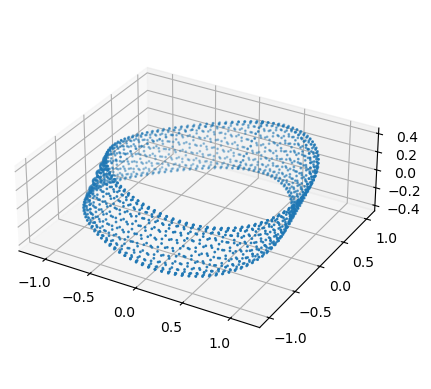

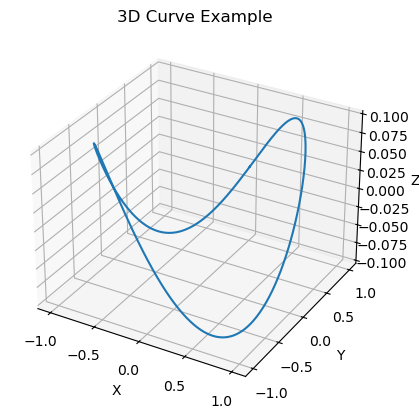

In [36]:
def generate_tube(curve, tube_radius):
    phis = torch.linspace(0, 2 * torch.pi, 100, requires_grad=True)  # Using torch.linspace
    thetas = torch.linspace(0, 2 * torch.pi, 20, requires_grad=True)  # Using torch.linspace
    
    data = []
    for phi in phis:
        frame, _, _ = compute_frenet_frame(curve, phi, 10)
        e1 = frame[:, 0]
        e2 = frame[:, 1]
        center = curve(phi)
        for theta in thetas:
            offset = tube_radius * torch.cos(theta) * e1 + tube_radius * torch.sin(theta) * e2
            point = center + offset
            data.append(point)

    return torch.stack(data)

# Generate data for tube
tube_radius = 1
data = generate_tube(scrunchy_curve_10, tube_radius)

# Plot 3D scatter plot
data_numpy = data.detach().numpy()

# Plot 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_numpy[:, 0], data_numpy[:, 1], data_numpy[:, 2], s=1)
ax.set_aspect('equal')
plt.show()


# Generate t values
t_values = torch.linspace(0, 2 * torch.pi, 500)

# Evaluate the curve at each t value
curve_points = torch.stack([scrunchy_curve_10(t) for t in t_values])

# Convert the curve points to NumPy for plotting
curve_points_numpy = curve_points.detach().numpy()

# Plot the curve
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot x, y, and z values
ax.plot(curve_points_numpy[:, 0], curve_points_numpy[:, 1], curve_points_numpy[:, 2])

# Set labels and display the plot
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Curve Example')

plt.show()

[-0.01113499  0.968149   -0.02496236 -0.00933136 -0.03740108 -0.14014646
 -0.04689626 -0.3473172  -0.0497412  -0.7499681 ]


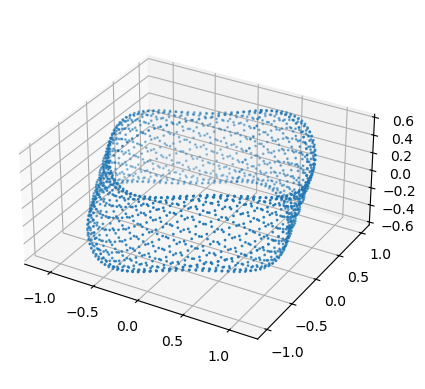

In [37]:
print(data_numpy[5])

# Plot 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_numpy[:, 0], data_numpy[:, 1], data_numpy[:, 4], s=1)
ax.set_aspect('equal')
plt.show()


In [38]:
import warnings
import numpy as np

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PairwiseDistance
from gtda.diagrams import BettiCurve
from gtda.diagrams import Scaler

def compute_persistence_diagrams(point_clouds, homology_dimensions, scale):
    print("Computing persistence diagrams")
    persistence = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=homology_dimensions,
        n_jobs=6,
        collapse_edges=True,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        diagrams = persistence.fit_transform(point_clouds)

        if scale:
            scaler = Scaler()
            diagrams = scaler.fit_transform(diagrams)

    return diagrams

def plot_persistence_diagrams(diagrams, homology_dimensions):
    """Plot two persistence diagrams side-by-side and print bottleneck distance matrix."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), )
    titles = ["Persistence Diagram for Input Data", "Persistence Diagram for Latent Representation"]
    colors = {0: 'red', 1: 'blue', 2: 'green'}

    for i, ax in enumerate(axes):
        diagram = diagrams[i]
        diagram = diagram[diagram[:, 0] != diagram[:, 1]]
        bd = diagram[:, :2]

        posinf_mask = np.isposinf(bd)
        neginf_mask = np.isneginf(bd)

        if bd.size:
            max_val = np.max(np.where(posinf_mask, -np.inf, bd))
            min_val = np.min(np.where(neginf_mask, np.inf, bd))
        else:
            max_val, min_val = 1.0, 0.0

        value_range = max_val - min_val
        buffer = 0.05 * value_range
        min_val_display = min_val - buffer
        max_val_display = max_val + buffer

        ax.plot([min_val_display, max_val_display], [min_val_display, max_val_display],
                linestyle='--', color='black', linewidth=1)

        for dim in homology_dimensions:
            subdiagram = diagram[diagram[:, 2] == dim]
            births = subdiagram[:, 0]
            deaths = subdiagram[:, 1]
            deaths = np.where(np.isposinf(deaths), max_val_display + 0.05 * value_range, deaths)

            label = f"$H_{dim}$"
            ax.scatter(births, deaths, label=label, color=colors.get(dim, 'gray'), s=20)

        ax.set_title(titles[i])
        ax.set_xlabel("Birth")
        ax.set_ylabel("Death")
        ax.set_xlim([min_val_display, max_val_display])
        ax.set_ylim([min_val_display, max_val_display])
        ax.set_aspect("equal")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
    

In [39]:
diagram = compute_persistence_diagrams([data_numpy], [0,1,2],scale=True)

Computing persistence diagrams


KeyboardInterrupt: 

In [ ]:
plot_persistence_diagrams(diagram, [0,1,2])

In [33]:
import os
import numpy as np
import torch
from tqdm import tqdm

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from numpy.linalg import lstsq


def estimate_curvature_2d_quadric(points, k=200):
    n, d = points.shape
    nbrs = NearestNeighbors(n_neighbors=k).fit(points)
    _, indices = nbrs.kneighbors(points)
    curvatures = []
    for i in tqdm(range(n), desc="Estimating 2D curvature", leave=False):
        neighbors = points[indices[i]]
        centroid = neighbors.mean(axis=0)
        centered = neighbors - centroid
        pca = PCA(n_components=3).fit(centered)
        normal = pca.components_[-1]
        tangent = pca.components_[:2]
        local_coords = centered @ tangent.T
        heights = centered @ normal
        X, Y = local_coords[:, 0], local_coords[:, 1]
        A = np.column_stack([X ** 2, Y ** 2, X * Y, X, Y, np.ones_like(X)])
        coeffs, _, _, _ = lstsq(A, heights, rcond=None)
        a, b, c = coeffs[0], coeffs[1], coeffs[2]
        II = np.array([[2 * a, c], [c, 2 * b]])
        H = 0.5 * np.trace(II)
        curvatures.append(abs(H))
    return np.array(curvatures)

curvatures = estimate_curvature_2d_quadric(data_numpy)

In [34]:
def _scatter_datapoints(ax, data, title, colors=None, cmap='hsv'):
    d = data.shape[1]
    pca_applied = False
    dot_size = 3

    if d == 1:
        sc = ax.scatter(data[:, 0], np.zeros_like(data[:, 0]), c=colors, cmap=cmap, s=dot_size, alpha=0.7)
        ax.set_yticks([])
    elif d == 2:
        sc = ax.scatter(data[:, 0], data[:, 1], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
    elif d == 3:
        sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
    else:
        data = PCA(n_components=3).fit_transform(data)
        sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
        pca_applied = True

    title_suffix = " (PCA)" if pca_applied else ""
    ax.set_title(f"{title}{title_suffix}")
    ax.set_aspect('equal', adjustable='datalim')

    return sc

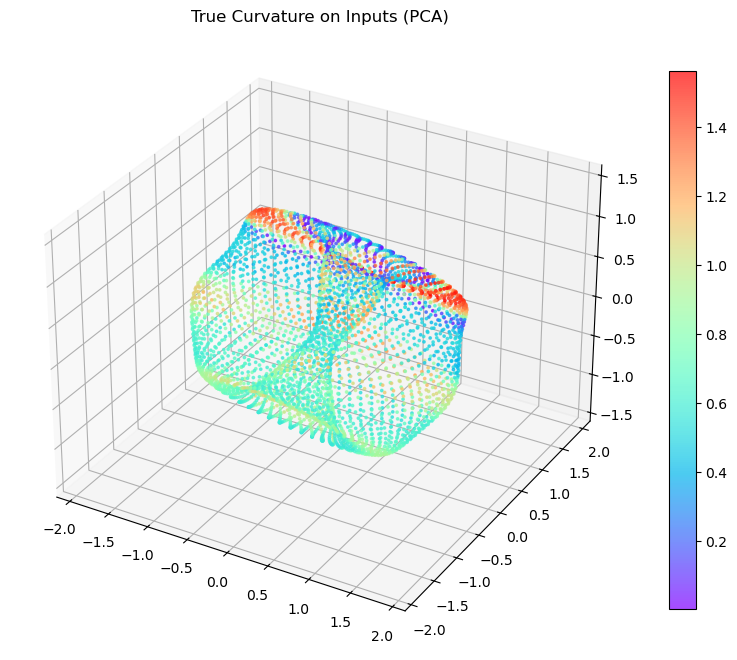

In [35]:
fig = plt.figure(figsize=(10, 10))
color_map = 'rainbow'

# True Curvature on Inputs
ax1 = fig.add_subplot(1, 1, 1, projection='3d' if data_numpy.shape[1] == 3 or data_numpy.shape[1] > 3 else None)
sc1 = _scatter_datapoints(ax=ax1, data=data_numpy, title="True Curvature on Inputs", colors=curvatures,
                          cmap=color_map)
fig.colorbar(sc1, ax=ax1, shrink=0.7)